# Distributed Order Management (DOM) - Mixed Integer Linear Programming (MILP)

**Quantum Optimization for Distributed Order Management**

QAOA is parked for now (qubit ceiling). This notebook runs only the two
classical baselines and the 7-constraint MILP (PuLP + CBC), against the
**complete focus-order set** - every focus order, every PGI date in the
window, every non-default DC as a candidate - for each of the 5 target
planning dates(06-20, 06-21, 06-22, 06-23, 06-24).

### What to upload before running
- `input_order_data.csv`
- `input_capacity_planning.csv`
- `input_dock_capacity.csv`
- `input_shipping_cost_data.csv`
- `input_throughput_capacity.csv`

## Requirements

In [1]:
%pip install -q pulp==2.9.0

import os
import re
import tempfile
import time
import numpy as np
import pandas as pd
from itertools import product

print("Imports OK")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 84.1 MB/s eta 0:00:00
Imports OK


## Specify the Location of the CSV Files

The cell below automatically locates the required CSV files, whether they
are stored in the current Colab environment, on your Google Drive, or need
to be uploaded.

In [2]:
from google.colab import drive

REQUIRED_FILES = [
    "input_order_data.csv", "input_capacity_planning.csv",
    "input_dock_capacity.csv", "input_shipping_cost_data.csv",
    "input_throughput_capacity.csv",
]

def all_files_here(root):
    return all(os.path.exists(f"{root}/{f}") for f in REQUIRED_FILES)

DRIVE_FOLDER = "/content/drive/MyDrive/nestle_dom_data"
drive.mount("/content/drive")

if all_files_here(DRIVE_FOLDER):
    DATA_ROOT = DRIVE_FOLDER
elif all_files_here("."):
    DATA_ROOT = "."
elif all_files_here("/content"):
    DATA_ROOT = "/content"
else:
    from google.colab import files
    print(f"Please select the {len(REQUIRED_FILES)} CSV files:")
    files.upload()
    DATA_ROOT = "/content"

missing = [f for f in REQUIRED_FILES if not os.path.exists(f"{DATA_ROOT}/{f}")]
if missing:
    raise FileNotFoundError(f"Still missing: {missing}")

print(f"CSVs found at: {DATA_ROOT}")


Mounted at /content/drive
CSVs found at: /content/drive/MyDrive/nestle_dom_data


## The library

1. **Config + data loading** - `RunConfig`, `DomData`, `load_dom_data`, `filter_focus_orders`
2. **Instance building** - `build_instance` keeps every focus order, every PGI date, every non-default DC
3. **Feasibility** - `decode`, `repair`, `get_capacity_rows`
4. **Solvers** - `run_baseline_default_dc`, `run_baseline_greedy`, `run_milp`
5. **Metrics** - `recovery_prf` (P/R/F1), `comparison_table`, `save_result`

In [3]:
# ---------------------------------------------------------------------------
# Config + data loading
# ---------------------------------------------------------------------------

class RunConfig:
    """Planning-day window + capacity sensitivity knob.
    No order/alternate cap of any kind -- build_instance always keeps every
    focus order and every non-default DC as a candidate.
    """
    def __init__(self, current_date="2024-06-20", capacity_tightness=1.0,
                 use_throughput_cap=False):
        self.current_date = current_date              # planning day
        self.horizon_lo_days = 3                       # window start (days from today)
        self.horizon_hi_days = 10                      # window end
        self.capacity_tightness = capacity_tightness   # <1.0 shrinks caps for sensitivity
        # input_throughput_capacity.csv has util_case_picks / util_pallets /
        # order_count -- these look like UTILISATION, not a capacity ceiling
        # (many days are 0). Treating them as a cap blocked ~half the orders,
        # so it is OFF by default. Turn on only if the data owner confirms
        # util_case_picks really is the daily case-pick capacity.
        self.use_throughput_cap = use_throughput_cap


class DomData:
    def __init__(self, orders, inventory, dock, shipping, throughput):
        self.orders = orders
        self.inventory = inventory
        self.dock = dock
        self.shipping = shipping
        self.throughput = throughput


def load_dom_data(root="."):
    orders = pd.read_csv(f"{root}/input_order_data.csv")
    orders["transportationplanningdate"] = pd.to_datetime(
        orders["transportationplanningdate"], format="%m/%d/%y", errors="coerce")

    inventory = pd.read_csv(
        f"{root}/input_capacity_planning.csv",
        usecols=["LocationID", "MaterialID", "DATE", "Available_inventory"])
    inventory["DATE"] = pd.to_datetime(inventory["DATE"]).dt.strftime("%Y-%m-%d")

    dock = pd.read_csv(f"{root}/input_dock_capacity.csv")
    dock["Date"] = pd.to_datetime(dock["Date"], format="%m/%d/%y", errors="coerce"
                                  ).dt.strftime("%Y-%m-%d")

    shipping = pd.read_csv(f"{root}/input_shipping_cost_data.csv")

    throughput = pd.read_csv(f"{root}/input_throughput_capacity.csv")
    throughput["transportationplanningdate"] = pd.to_datetime(
        throughput["transportationplanningdate"]).dt.strftime("%Y-%m-%d")

    return DomData(orders, inventory, dock, shipping, throughput)


def filter_focus_orders(data, cfg):
    """Pick out orders where the default DC has insufficient stock and it's FTL."""
    current_dt = pd.to_datetime(cfg.current_date)
    window_start = current_dt + pd.Timedelta(days=cfg.horizon_lo_days)
    window_end = current_dt + pd.Timedelta(days=cfg.horizon_hi_days)

    in_window = data.orders[data.orders["transportationplanningdate"].between(
        window_start, window_end)].copy()
    if in_window.empty:
        raise RuntimeError(f"no orders in window {window_start.date()}..{window_end.date()}")
    in_window["pgi"] = in_window["transportationplanningdate"].dt.strftime("%Y-%m-%d")

    inventory_dict = (data.inventory
                      .groupby(["LocationID", "MaterialID", "DATE"])
                      ["Available_inventory"].sum().clip(lower=0).to_dict())

    order_groups = dict(list(in_window.groupby("Group_Flag")))
    priorities = in_window.groupby("Group_Flag")["DeliveryPriority"].first()

    # Priority-8 orders "eat" default-DC inventory first
    ordered_priority = [o for o, p in priorities.items() if p == 8]
    ordered_priority += [o for o in order_groups if o not in set(ordered_priority)]

    running_inventory = dict(inventory_dict)
    is_short = {}
    for order_id in ordered_priority:
        rows = order_groups[order_id]
        default_dc = rows["Plant"].iloc[0]
        pgi = rows["pgi"].iloc[0]
        short = False
        for _, row in rows.iterrows():
            key = (default_dc, row["MaterialNumber"], pgi)
            available = running_inventory.get(key, 0.0)
            if available < row["OrderedQty_converted"]:
                short = True
            running_inventory[key] = available - min(row["OrderedQty_converted"], available)
        is_short[order_id] = short

    kept_rows = [g for o, g in order_groups.items()
                 if is_short.get(o, False) and g["IsFTL"].iloc[0] == "Y"]
    if not kept_rows:
        raise RuntimeError("no focus orders — try a different date")
    return pd.concat(kept_rows, ignore_index=True)


In [4]:
# ---------------------------------------------------------------------------
# Instance building -- every focus order, every PGI date, every non-default DC
# ---------------------------------------------------------------------------

class Column:
    def __init__(self, index, order_id, plant_id, is_default, pgi_date,
                 revenue, shipping_cost, penalty, cases_filled, cases_demanded,
                 fill_by_material, case_picks_used):
        self.index = index
        self.order_id = order_id
        self.plant_id = plant_id           # None = unassigned column
        self.is_default = is_default
        self.pgi_date = pgi_date
        self.revenue = revenue
        self.shipping_cost = shipping_cost
        self.penalty = penalty
        self.cases_filled = cases_filled
        self.cases_demanded = cases_demanded
        self.fill_by_material = fill_by_material  # {sku: cases}
        self.case_picks_used = case_picks_used

    @property
    def profit(self):
        return self.revenue - self.shipping_cost - self.penalty

    @property
    def is_unassigned(self):
        return self.plant_id is None

    def label(self):
        target = "NONE" if self.is_unassigned else self.plant_id
        return f"order_{self.order_id}@{target}"


class Instance:
    def __init__(self, columns, blocks, order_ids,
                 inventory_cap, dock_cap, throughput_cap, case_pick_cap,
                 order_info=None):
        self.columns = columns              # list of Column
        self.blocks = blocks                # list of lists — column indices per order
        self.order_ids = order_ids
        self.inventory_cap = inventory_cap  # (dc, sku, date) -> cases
        self.dock_cap = dock_cap            # (dc, date) -> orders
        self.throughput_cap = throughput_cap  # (dc, date) -> total cases
        self.case_pick_cap = case_pick_cap  # (dc, date) -> case-picks
        # order -> {priority, pgi, default_dc, threshold, lines:[(sku, qty, price, penalty_rate, cases_per_pallet)]}
        self.order_info = order_info

    @property
    def n_vars(self):
        return len(self.columns)

    def profits(self):
        return np.array([c.profit for c in self.columns], dtype=float)


def _get_shipping_cost_lookup(data, focus):
    ship_table = data.shipping.set_index(["TargetZip", "Plant"])["Shipping_Cost"].to_dict()
    plant_avg = data.shipping.groupby("Plant")["Shipping_Cost"].mean().to_dict()
    zip_of = focus.groupby("Group_Flag")["ZipCode"].first().to_dict()

    def lookup(order_id, plant_id):
        return float(ship_table.get((zip_of.get(order_id), plant_id),
                                    plant_avg.get(plant_id, 5000.0)))
    return lookup


def build_instance(data, focus, cfg):
    """Every focus order, every PGI date in the horizon window, every
    non-default DC as a candidate alternate, plus an 'unassigned' fallback.
    """
    inventory = (data.inventory
                 .groupby(["LocationID", "MaterialID", "DATE"])["Available_inventory"]
                 .sum().clip(lower=0).to_dict())
    shipping_cost = _get_shipping_cost_lookup(data, focus)
    all_plants = sorted(set(data.inventory["LocationID"]) & set(data.shipping["Plant"]))

    demand = focus.set_index(["Group_Flag", "MaterialNumber"])["OrderedQty_converted"].to_dict()
    line_revenue = focus.set_index(["Group_Flag", "MaterialNumber"])["Order_SKU_Revenue"].to_dict()
    penalty_rate = focus.set_index(["Group_Flag", "MaterialNumber"])["Penaltyforpotentialcuts"].to_dict()
    cases_per_pallet = focus.set_index(["Group_Flag", "MaterialNumber"])["ProductCasesPerPallet"].to_dict()
    average_penalty = float(np.nan_to_num(focus["Penaltyforpotentialcuts"].mean()))
    fill_rate_threshold = focus.groupby("Group_Flag")["FillRateThreshold"].first().to_dict()
    mean_threshold = float(np.nan_to_num(focus["FillRateThreshold"].mean(), nan=1.0))

    def unit_price(order_id, sku):
        revenue = float(line_revenue.get((order_id, sku), 0.0))
        qty = float(demand.get((order_id, sku), 0.0))
        return revenue / qty if qty > 0 else 0.0

    lines_by_order = dict(list(focus.groupby("Group_Flag")))
    default_dc_of = focus.groupby("Group_Flag")["Plant"].first().to_dict()
    pgi_of = focus.groupby("Group_Flag")["pgi"].first().to_dict()

    def score_assignment(order_id, plant_id):
        pgi = pgi_of[order_id]
        fill_by_sku = {}
        revenue = shortfall_penalty = filled = demanded = 0.0
        case_picks_used = 0.0
        for _, row in lines_by_order[order_id].iterrows():
            sku = row["MaterialNumber"]
            qty = float(row["OrderedQty_converted"])
            price = unit_price(order_id, sku)
            available_at_plant = (float(inventory.get((plant_id, sku, pgi), 0.0))
                                  if plant_id is not None else 0.0)
            got = min(qty, available_at_plant)
            fill_by_sku[sku] = got
            revenue += got * price
            filled += got
            demanded += qty
            cpp = max(1, int(cases_per_pallet.get((order_id, sku), 60) or 60))
            case_picks_used += got % cpp
            rate = penalty_rate.get((order_id, sku), average_penalty)
            rate = average_penalty if pd.isna(rate) else float(rate)
            shortfall_penalty += (qty - got) * price * rate
        threshold_pct = fill_rate_threshold.get(order_id, mean_threshold)
        threshold_pct = mean_threshold if pd.isna(threshold_pct) else float(threshold_pct)
        met_threshold = (demanded > 0) and (filled >= threshold_pct * demanded)
        penalty = 0.0 if met_threshold else shortfall_penalty
        return {
            "revenue": revenue, "cases_filled": filled, "cases_demanded": demanded,
            "penalty": penalty, "fill_by_material": fill_by_sku,
            "case_picks_used": case_picks_used,
        }

    selected_orders = list(lines_by_order.keys())   # every focus order

    columns = []
    blocks = []
    used_inventory_keys = {}

    for order_id in selected_orders:
        default_dc = default_dc_of[order_id]
        pgi = pgi_of[order_id]
        alternates = [p for p in all_plants if p != default_dc]   # every alternate

        block_indices = []
        for plant in [default_dc, *alternates]:
            result = score_assignment(order_id, plant)
            columns.append(Column(
                index=len(columns), order_id=order_id, plant_id=plant,
                is_default=(plant == default_dc), pgi_date=pgi,
                revenue=result["revenue"], shipping_cost=shipping_cost(order_id, plant),
                penalty=result["penalty"], cases_filled=result["cases_filled"],
                cases_demanded=result["cases_demanded"],
                fill_by_material=result["fill_by_material"],
                case_picks_used=result["case_picks_used"]))
            block_indices.append(columns[-1].index)
            for sku, filled in result["fill_by_material"].items():
                if filled > 0:
                    used_inventory_keys[(plant, sku, pgi)] = float(inventory.get((plant, sku, pgi), 0.0))

        # "Leave unassigned" fallback column
        result = score_assignment(order_id, default_dc)
        total_shortfall_penalty = sum(
            float(demand.get((order_id, s), 0.0)) * unit_price(order_id, s)
            * (average_penalty if pd.isna(penalty_rate.get((order_id, s)))
               else float(penalty_rate[(order_id, s)]))
            for s in lines_by_order[order_id]["MaterialNumber"])
        columns.append(Column(
            index=len(columns), order_id=order_id, plant_id=None, is_default=False,
            pgi_date=pgi, revenue=0.0, shipping_cost=0.0, penalty=total_shortfall_penalty,
            cases_filled=0.0, cases_demanded=result["cases_demanded"],
            fill_by_material={}, case_picks_used=0.0))
        block_indices.append(columns[-1].index)
        blocks.append(block_indices)

    dock_all = data.dock.copy()
    dock_all["rem"] = dock_all["Dock_Remaining"].clip(lower=0)
    dock_lookup = dock_all.groupby(["Plant", "Date"])["rem"].max().to_dict()
    throughput_lookup = (data.throughput
                        .groupby(["Plant", "transportationplanningdate"])["util_case_picks"]
                        .max().to_dict())

    plant_date_pairs = {(c.plant_id, c.pgi_date) for c in columns if not c.is_unassigned}
    t = cfg.capacity_tightness

    def _cpp(v):
        try:
            v = int(v)
            return v if v > 0 else 60
        except (TypeError, ValueError):
            return 60

    order_info = {}
    for order_id, lines in lines_by_order.items():
        thr = fill_rate_threshold.get(order_id, mean_threshold)
        thr = mean_threshold if pd.isna(thr) else float(thr)
        parsed = []
        for _, row in lines.iterrows():
            sku = row["MaterialNumber"]
            rate = penalty_rate.get((order_id, sku), average_penalty)
            rate = average_penalty if pd.isna(rate) else float(rate)
            parsed.append((sku, float(row["OrderedQty_converted"]),
                           unit_price(order_id, sku), rate,
                           _cpp(cases_per_pallet.get((order_id, sku), 60))))
        order_info[order_id] = {
            "priority": lines["DeliveryPriority"].iloc[0],
            "pgi": pgi_of[order_id], "default_dc": default_dc_of[order_id],
            "threshold": thr, "lines": parsed,
        }

    use_thr = getattr(cfg, "use_throughput_cap", False)
    return Instance(
        columns=columns, blocks=blocks, order_ids=selected_orders, order_info=order_info,
        inventory_cap={k: v * t for k, v in used_inventory_keys.items()},
        dock_cap={k: float(dock_lookup[k]) * t for k in plant_date_pairs if k in dock_lookup},
        throughput_cap={k: float(throughput_lookup[k]) * t
                        for k in plant_date_pairs if use_thr and k in throughput_lookup},
        case_pick_cap={k: float(throughput_lookup[k]) * t
                       for k in plant_date_pairs if use_thr and k in throughput_lookup},
    )


In [5]:
# ---------------------------------------------------------------------------
# Feasibility checking
# ---------------------------------------------------------------------------

class Solution:
    def __init__(self, x, profit, feasible, violations, fill_rate, n_diverted, selected,
                 revenue=None, shipping=None, penalty=None, n_dropped=0,
                 assign=None, allocation=None):
        self.revenue = revenue          # realized components (set by realize())
        self.shipping = shipping
        self.penalty = penalty
        self.n_dropped = n_dropped      # orders that lost their dock slot / case-pick room
        self.assign = assign            # order -> plant actually used (None = unserved)
        self.allocation = allocation    # (order, sku) -> cases actually shipped
        self.x = x
        self.profit = profit
        self.feasible = feasible
        self.violations = violations
        self.fill_rate = fill_rate
        self.n_diverted = n_diverted
        self.selected = selected


def get_capacity_rows(instance):
    rows = []
    columns = instance.columns

    for (plant, date), cap in instance.dock_cap.items():
        coef = {c.index: 1.0 for c in columns
                if not c.is_unassigned and c.plant_id == plant and c.pgi_date == date}
        if coef:
            rows.append((coef, cap, f"dock[{plant},{date}]"))

    for (plant, sku, date), cap in instance.inventory_cap.items():
        coef = {c.index: c.fill_by_material.get(sku, 0.0) for c in columns
                if not c.is_unassigned and c.plant_id == plant and c.pgi_date == date}
        coef = {i: v for i, v in coef.items() if v > 0}
        if coef:
            rows.append((coef, cap, f"inv[{plant},{sku},{date}]"))

    for (plant, date), cap in instance.throughput_cap.items():
        coef = {c.index: c.cases_filled for c in columns
                if not c.is_unassigned and c.plant_id == plant
                and c.pgi_date == date and c.cases_filled > 0}
        if coef:
            rows.append((coef, cap, f"thru[{plant},{date}]"))

    for (plant, date), cap in instance.case_pick_cap.items():
        coef = {c.index: c.case_picks_used for c in columns
                if not c.is_unassigned and c.plant_id == plant
                and c.pgi_date == date and c.case_picks_used > 0}
        if coef:
            rows.append((coef, cap, f"casepicks[{plant},{date}]"))

    binding = [(coef, cap, label) for coef, cap, label in rows
               if len(coef) > 1 or max(coef.values()) > cap + 1e-9]
    return binding


def decode(instance, x):
    """Turn a bitstring into a Solution. Checks constraints, computes profit."""
    violations = []

    for block_idx, block in enumerate(instance.blocks):
        if abs(sum(x[i] for i in block) - 1.0) > 1e-9:
            violations.append(f"one-hot[order_{instance.order_ids[block_idx]}]")

    for coef, cap, label in get_capacity_rows(instance):
        used = sum(v * x[i] for i, v in coef.items())
        if used > cap + 1e-6:
            violations.append(f"{label} {used:.0f}>{cap:.0f}")

    selected = [i for i in range(instance.n_vars) if x[i] > 0.5]
    profit = sum(instance.columns[i].profit for i in selected)
    filled = sum(instance.columns[i].cases_filled for i in selected)
    demanded = sum(instance.columns[b[0]].cases_demanded for b in instance.blocks)
    n_diverted = sum(1 for i in selected
                     if not instance.columns[i].is_unassigned
                     and not instance.columns[i].is_default)

    return Solution(
        x=x.copy(), profit=profit, feasible=not violations,
        violations=violations,
        fill_rate=filled / demanded if demanded > 0 else 0.0,
        n_diverted=n_diverted, selected=selected)


def repair(instance, x):
    """Fix an infeasible bitstring: pick best column per block, drop violators."""
    y = np.zeros_like(x)
    profits = instance.profits()
    for block in instance.blocks:
        active = [i for i in block if x[i] > 0.5]
        chosen = max(active, key=lambda i: profits[i]) if active else block[-1]
        y[chosen] = 1.0

    rows = get_capacity_rows(instance)
    unassigned_column_of = {b_idx: block[-1] for b_idx, block in enumerate(instance.blocks)}

    for _ in range(instance.n_vars):
        worst = None
        for coef, cap, _ in rows:
            used = sum(v * y[i] for i, v in coef.items())
            if used > cap + 1e-6:
                active = [i for i, v in coef.items() if y[i] > 0.5 and v > 0]
                if active:
                    worst = min(active, key=lambda i: profits[i])
                    break
        if worst is None:
            return y

        block_idx = next(bi for bi, block in enumerate(instance.blocks) if worst in block)
        y[worst] = 0.0
        y[unassigned_column_of[block_idx]] = 1.0
    return y


class SolverReport:
    def __init__(self, name, solution, runtime_s, n_samples,
                 feasible_fraction, extra=None):
        self.name = name
        self.solution = solution
        self.runtime_s = runtime_s
        self.n_samples = n_samples
        self.feasible_fraction = feasible_fraction
        self.extra = extra or {}


def order_sequence(instance):
    """Order in which stock and dock slots are handed out: priority-8 orders
    first (same rule filter_focus_orders uses), then the rest in instance order."""
    idx = {o: k for k, o in enumerate(instance.order_ids)}
    return sorted(instance.order_ids,
                  key=lambda o: (0 if instance.order_info[o]["priority"] == 8 else 1, idx[o]))


def realize(instance, assign, allocation=None):
    info = instance.order_info
    ship = {(c.order_id, c.plant_id): c.shipping_cost
            for c in instance.columns if not c.is_unassigned}
    stock = dict(instance.inventory_cap)
    dock_used, cp_used, tot_used = {}, {}, {}
    final_assign, fills, n_dropped = {}, {}, 0

    for o in order_sequence(instance):
        oi = info[o]
        pgi = oi["pgi"]
        p = assign.get(o)
        fill_o = {}
        if p is not None:
            key = (p, pgi)
            dcap = instance.dock_cap.get(key)
            if dcap is not None and dock_used.get(key, 0) + 1 > dcap + 1e-9:
                p = None
                n_dropped += 1
        if p is not None:
            tentative, cp_o, tot_o = {}, 0.0, 0.0
            for sku, qty, price, rate, cpp in oi["lines"]:
                avail = stock.get((p, sku, pgi), 0.0)
                want = qty if allocation is None else min(qty, allocation.get((o, sku), 0.0))
                got = max(0.0, min(want, avail))
                tentative[sku] = got
                cp_o += got % cpp
                tot_o += got
            ccap = instance.case_pick_cap.get(key)
            tcap = instance.throughput_cap.get(key)
            if ((ccap is not None and cp_used.get(key, 0.0) + cp_o > ccap + 1e-9) or
                    (tcap is not None and tot_used.get(key, 0.0) + tot_o > tcap + 1e-9)):
                p = None
                n_dropped += 1
            else:
                for sku, got in tentative.items():
                    stock[(p, sku, pgi)] = stock.get((p, sku, pgi), 0.0) - got
                fill_o = tentative
                dock_used[key] = dock_used.get(key, 0) + 1
                cp_used[key] = cp_used.get(key, 0.0) + cp_o
                tot_used[key] = tot_used.get(key, 0.0) + tot_o
        final_assign[o] = p
        for sku, got in fill_o.items():
            fills[(o, sku)] = got

    revenue = shipping = penalty = filled_all = demanded_all = 0.0
    x = np.zeros(instance.n_vars)
    selected, n_diverted = [], 0
    for b_idx, block in enumerate(instance.blocks):
        o = instance.order_ids[b_idx]
        oi = info[o]
        dem = fil = rev = shortfall = 0.0
        for sku, qty, price, rate, cpp in oi["lines"]:
            got = fills.get((o, sku), 0.0)
            dem += qty
            fil += got
            rev += got * price
            shortfall += (qty - got) * price * rate
        pen = 0.0 if fil >= oi["threshold"] * dem - 1e-9 else shortfall
        p = final_assign[o] if fil > 0 else None
        ship_cost = ship.get((o, p), 0.0) if p is not None else 0.0
        revenue += rev
        shipping += ship_cost
        penalty += pen
        filled_all += fil
        demanded_all += dem
        if p is not None and p != oi["default_dc"]:
            n_diverted += 1
        col = next((i for i in block if instance.columns[i].plant_id == p), block[-1])
        x[col] = 1.0
        selected.append(col)

    profit = revenue - shipping - penalty
    return Solution(
        x=x, profit=profit, feasible=True, violations=[],
        fill_rate=filled_all / demanded_all if demanded_all > 0 else 0.0,
        n_diverted=n_diverted, selected=selected,
        revenue=revenue, shipping=shipping, penalty=penalty, n_dropped=n_dropped,
        assign=final_assign, allocation=fills)


In [6]:
# ---------------------------------------------------------------------------
# Solvers: baselines + MILP
# ---------------------------------------------------------------------------

def run_baseline_default_dc(instance):
    """Baseline 1: every order stays at its default DC; stock is handed out
    sequentially (priority-8 first) and short orders keep their partial fill."""
    t0 = time.perf_counter()
    assign = {o: instance.order_info[o]["default_dc"] for o in instance.order_ids}
    sol = realize(instance, assign)
    return SolverReport(
        name="Baseline 1: Default DC",
        solution=sol, runtime_s=time.perf_counter() - t0,
        n_samples=1, feasible_fraction=float(sol.feasible))


def run_baseline_greedy(instance, hurdle_pct=0.05, hurdle_cases=100.0):
    """Baseline 2: greedy sequential. Orders are handled one by one against
    the LIVE remaining stock and dock slots; an order leaves its default DC
    only if another DC fills at least max(hurdle_pct*demand, hurdle_cases)
    more cases, and among those it takes the DC with the highest fill."""
    t0 = time.perf_counter()
    info = instance.order_info
    cands = {}
    for b_idx, block in enumerate(instance.blocks):
        cands[instance.order_ids[b_idx]] = [instance.columns[i].plant_id for i in block
                                            if not instance.columns[i].is_unassigned]
    stock = dict(instance.inventory_cap)
    dock_used, assign = {}, {}

    for o in order_sequence(instance):
        oi = info[o]
        pgi, default_p = oi["pgi"], oi["default_dc"]
        demanded = sum(line[1] for line in oi["lines"])
        hurdle = max(hurdle_pct * demanded, hurdle_cases)

        def fill_at(p):
            return sum(min(line[1], stock.get((p, line[0], pgi), 0.0)) for line in oi["lines"])

        def dock_ok(p):
            cap = instance.dock_cap.get((p, pgi))
            return cap is None or dock_used.get((p, pgi), 0) + 1 <= cap + 1e-9

        default_fill = fill_at(default_p)
        best_p = default_p if dock_ok(default_p) else None
        best_fill = default_fill if best_p is not None else 0.0
        for p in cands[o]:
            if p == default_p or not dock_ok(p):
                continue
            f = fill_at(p)
            if f > best_fill and (f - default_fill) >= hurdle:
                best_p, best_fill = p, f
        assign[o] = best_p
        if best_p is not None:
            dock_used[(best_p, pgi)] = dock_used.get((best_p, pgi), 0) + 1
            for sku, qty, *_ in oi["lines"]:
                k = (best_p, sku, pgi)
                stock[k] = stock.get(k, 0.0) - min(qty, stock.get(k, 0.0))

    sol = realize(instance, assign)
    return SolverReport(
        name=f"Baseline 2: Greedy Sequential (>={int(hurdle_pct*100)}% or {int(hurdle_cases)} cases)",
        solution=sol, runtime_s=time.perf_counter() - t0,
        n_samples=1, feasible_fraction=float(sol.feasible))


def solution_breakdown(instance, solution):
    if solution.revenue is not None:      # realized (partial-fill) components
        return {"revenue": solution.revenue, "shipping_cost": solution.shipping,
                "penalty_cost": solution.penalty}
    return {
        "revenue": sum(instance.columns[i].revenue for i in solution.selected),
        "shipping_cost": sum(instance.columns[i].shipping_cost for i in solution.selected),
        "penalty_cost": sum(instance.columns[i].penalty for i in solution.selected),
    }


def run_milp(instance, data, solver_time_limit=300, verbose=False,
             hurdle_pct=0.05, hurdle_cases=100.0, min_fill_rate=None):
    """Solve the PoC problem with PuLP + CBC.
    Constraints:
      C1: at most one DC per order (binary A[order, dc])
      C2: cases filled <= ordered qty when assigned
      C3a: total cases at (dc, sku, date) <= available inventory
      C3b: non-default diverts can't steal inventory needed in next 5 days
      C4: divert must clear 5% + 100 case hurdle vs default
      C5: pallet + case-pick decomposition (integer arithmetic)
      C6: dock and throughput capacity per (dc, date)
      C7: penalty activation (Activation1/2 with fill-rate threshold)
      C8 (optional): network-wide fill rate >= min_fill_rate, if given.
        Off by default -- the model maximizes PROFIT, not fill rate, so it
        will happily leave a low-margin/high-shipping-cost order under-filled
        if completing it isn't worth it. Set min_fill_rate (e.g. 0.9) to see
        the $ cost of forcing a higher service level.
    Each order's own pgi date (order_pgi[o]) is used throughout, so this
    works whether the instance spans one date or many.
    """
    import pulp
    t0 = time.perf_counter()

    order_lines = data.orders[data.orders["Group_Flag"].isin(instance.order_ids)].copy()
    order_lines["pgi"] = order_lines["transportationplanningdate"].dt.strftime("%Y-%m-%d")

    order_pgi_lookup = {instance.order_ids[bi]: instance.columns[block[0]].pgi_date
                        for bi, block in enumerate(instance.blocks)}
    order_lines = order_lines[order_lines.apply(
        lambda r: r["pgi"] == order_pgi_lookup.get(r["Group_Flag"]), axis=1)]

    inventory = (data.inventory.groupby(["LocationID", "MaterialID", "DATE"])
                 ["Available_inventory"].sum().clip(lower=0).to_dict())

    ship_table = data.shipping.set_index(["TargetZip", "Plant"])["Shipping_Cost"].to_dict()
    plant_avg = data.shipping.groupby("Plant")["Shipping_Cost"].mean().to_dict()
    zips = order_lines.groupby("Group_Flag")["ZipCode"].first().to_dict()

    def shipping_cost(order_id, plant_id):
        return float(ship_table.get((zips.get(order_id), plant_id),
                                    plant_avg.get(plant_id, 5000.0)))

    dock_cap = instance.dock_cap
    case_pick_cap = instance.case_pick_cap
    thru_cap = instance.throughput_cap
    inv_cap = instance.inventory_cap

    order_dcs = {}
    order_default_dc = {}
    order_pgi = {}
    for block_idx, block in enumerate(instance.blocks):
        o = instance.order_ids[block_idx]
        order_dcs[o] = [instance.columns[i].plant_id for i in block
                        if not instance.columns[i].is_unassigned]
        order_default_dc[o] = next(instance.columns[i].plant_id for i in block
                                   if instance.columns[i].is_default)
        order_pgi[o] = instance.columns[block[0]].pgi_date

    average_penalty = float(np.nan_to_num(order_lines["Penaltyforpotentialcuts"].mean()))
    demand = {}
    price = {}
    penalty_rate = {}
    cases_per_pallet = {}
    for _, row in order_lines.iterrows():
        o = row["Group_Flag"]
        s = row["MaterialNumber"]
        qty = float(row["OrderedQty_converted"])
        rev = float(row["Order_SKU_Revenue"])
        demand[(o, s)] = qty
        price[(o, s)] = rev / qty if qty > 0 else 0.0
        rate = row["Penaltyforpotentialcuts"]
        penalty_rate[(o, s)] = average_penalty if pd.isna(rate) else float(rate)
        cases_per_pallet[(o, s)] = max(1, int(row["ProductCasesPerPallet"]))

    order_skus = {o: sorted(order_lines[order_lines["Group_Flag"] == o]["MaterialNumber"].unique())
                  for o in instance.order_ids}

    n_pairs_before = sum(len(v) for v in order_dcs.values())
    for o in instance.order_ids:
        pgi = order_pgi[o]
        order_dcs[o] = [d for d in order_dcs[o]
                        if d == order_default_dc[o]
                        or any(float(inventory.get((d, s, pgi), 0.0)) > 0 for s in order_skus[o])]
    n_pairs_after = sum(len(v) for v in order_dcs.values())
    if verbose:
        print(f"Pruned zero-inventory (order, DC) candidates: {n_pairs_before} -> {n_pairs_after}")

    threshold_pct = order_lines.groupby("Group_Flag")["FillRateThreshold"].first().to_dict()
    mean_threshold = float(np.nan_to_num(order_lines["FillRateThreshold"].mean(), nan=1.0))

    total_demand = {o: sum(demand[(o, s)] for s in order_skus[o]) for o in instance.order_ids}
    threshold_cases = {}
    for o in instance.order_ids:
        t = threshold_pct.get(o, mean_threshold)
        t = mean_threshold if pd.isna(t) else float(t)
        threshold_cases[o] = t * total_demand[o]

    prob = pulp.LpProblem("DOM_MILP", pulp.LpMaximize)

    A = {(o, d): pulp.LpVariable(f"A_{o}_{d}", cat="Binary")
         for o in instance.order_ids for d in order_dcs[o]}

    valid_osd = [(o, s, d) for o in instance.order_ids for d in order_dcs[o]
                 for s in order_skus[o]
                 if d == order_default_dc[o]
                 or float(inventory.get((d, s, order_pgi[o]), 0.0)) > 0]
    if verbose:
        n_before = sum(len(order_skus[o]) for o in instance.order_ids for d in order_dcs[o])
        print(f"Pruned zero-inventory (order, sku, DC) triples: {n_before} -> {len(valid_osd)}")

    Cases = {(o, s, d): pulp.LpVariable(f"C_{o}_{s}_{d}", lowBound=0) for (o, s, d) in valid_osd}

    CasePicks = {}
    PalletPicks = {}
    for (o, s, d) in valid_osd:
        cpp = cases_per_pallet[(o, s)]
        CasePicks[(o, s, d)] = pulp.LpVariable(
            f"CP_{o}_{s}_{d}", lowBound=0, upBound=cpp - 1, cat="Integer")
        PalletPicks[(o, s, d)] = pulp.LpVariable(
            f"PP_{o}_{s}_{d}", lowBound=0, cat="Integer")

    Activation1 = {o: pulp.LpVariable(f"Act1_{o}", cat="Binary") for o in instance.order_ids}
    Activation2 = {o: pulp.LpVariable(f"Act2_{o}", cat="Binary") for o in instance.order_ids}
    PenaltyCases1 = {o: pulp.LpVariable(f"PC1_{o}", lowBound=0) for o in instance.order_ids}
    PenaltyCases2 = {o: pulp.LpVariable(f"PC2_{o}", lowBound=0) for o in instance.order_ids}

    cases_by_order = {}
    for (o, s, d) in Cases:
        cases_by_order.setdefault(o, []).append((o, s, d))
    OrderCases = {o: pulp.lpSum(Cases[k] for k in cases_by_order.get(o, []))
                  for o in instance.order_ids}
    avg_price = {o: sum(demand[(o, s)] * price[(o, s)] for s in order_skus[o])
                    / max(total_demand[o], 1.0) for o in instance.order_ids}
    avg_penalty_rate = {o: sum(demand[(o, s)] * penalty_rate[(o, s)] for s in order_skus[o])
                           / max(total_demand[o], 1.0) for o in instance.order_ids}

    revenue = pulp.lpSum(Cases[(o, s, d)] * price[(o, s)] for (o, s, d) in Cases)
    shipping = pulp.lpSum(shipping_cost(o, d) * A[(o, d)]
                          for o in instance.order_ids for d in order_dcs[o])
    penalty = pulp.lpSum(
        (total_demand[o] * Activation1[o] - PenaltyCases1[o])
        * avg_price[o] * avg_penalty_rate[o]
        for o in instance.order_ids)
    prob += revenue - penalty - shipping

    for o in instance.order_ids:
        prob += pulp.lpSum(A[(o, d)] for d in order_dcs[o]) <= 1, f"C1_{o}"

    for (o, s, d) in Cases:
        prob += Cases[(o, s, d)] <= A[(o, d)] * demand[(o, s)], f"C2_{o}_{s}_{d}"

    inv_groups = {}
    for (o, s, d) in Cases:
        p = order_pgi[o]
        inv_groups.setdefault((d, s, p), []).append((o, s, d))
    for (d, s, p), entries in inv_groups.items():
        avail = float(inv_cap.get((d, s, p), 0.0))
        prob += pulp.lpSum(Cases[e] for e in entries) <= avail, f"C3a_{d}_{s}_{p}"

    future_dates_cache = {}
    for (o, s, d) in Cases:
        if d == order_default_dc[o]:
            continue
        p = order_pgi[o]
        if p not in future_dates_cache:
            p_dt = pd.Timestamp(p)
            future_dates_cache[p] = [(p_dt + pd.Timedelta(days=k)).strftime("%Y-%m-%d") for k in range(6)]
        fwd_min = min([float(inventory.get((d, s, q), 0.0)) for q in future_dates_cache[p]] or [0.0])
        prob += Cases[(o, s, d)] <= fwd_min, f"C3b_{o}_{s}_{d}"

    for o in instance.order_ids:
        default_dc = order_default_dc[o]
        p = order_pgi[o]
        fillable_at_default = sum(
            min(demand[(o, s)], float(inv_cap.get((default_dc, s, p), 0.0)))
            for s in order_skus[o])
        hurdle = max(hurdle_pct * total_demand[o], hurdle_cases)
        BIG_M = 10 * total_demand[o] + 1000
        for d in order_dcs[o]:
            if d == default_dc:
                continue
            filled_at_d = pulp.lpSum(Cases[(o, s, d)] for s in order_skus[o] if (o, s, d) in Cases)
            prob += (filled_at_d - fillable_at_default
                     >= hurdle * A[(o, d)] - BIG_M * (1 - A[(o, d)])), f"C4_{o}_{d}"

    for (o, s, d), cases_var in Cases.items():
        cpp = cases_per_pallet[(o, s)]
        prob += (CasePicks[(o, s, d)] + PalletPicks[(o, s, d)] * cpp
                 == cases_var), f"C5_decomp_{o}_{s}_{d}"

    dc_pgi_pairs = {(d, order_pgi[o]) for o in instance.order_ids for d in order_dcs[o]}

    # Case-pick / throughput caps: only present when RunConfig.use_throughput_cap
    for d, p in dc_pgi_pairs:
        entries = [(o, s, d) for o in instance.order_ids
                   if d in order_dcs[o] and order_pgi[o] == p for s in order_skus[o]]
        if entries and (d, p) in case_pick_cap:
            prob += pulp.lpSum(CasePicks[e] for e in entries) <= case_pick_cap[(d, p)], f"C5_cap_{d}_{p}"
        if entries and (d, p) in thru_cap:
            prob += pulp.lpSum(Cases[e] for e in entries) <= thru_cap[(d, p)], f"C5_thru_{d}_{p}"

    # Dock appointments: one dock per order, only where the dock file has a row
    for d, p in dc_pgi_pairs:
        if (d, p) not in dock_cap:
            continue
        orders_at_dp = [o for o in instance.order_ids
                        if d in order_dcs[o] and order_pgi[o] == p]
        if orders_at_dp:
            prob += pulp.lpSum(A[(o, d)] for o in orders_at_dp) <= dock_cap[(d, p)], f"C6_{d}_{p}"

    for o in instance.order_ids:
        prob += Activation1[o] + Activation2[o] == 1, f"C7a_{o}"
        prob += PenaltyCases1[o] <= threshold_cases[o] * Activation1[o], f"C7b_{o}"
        prob += PenaltyCases2[o] >= threshold_cases[o] * Activation2[o], f"C7c_{o}"
        prob += PenaltyCases2[o] <= total_demand[o] * Activation2[o], f"C7d_{o}"
        prob += PenaltyCases1[o] + PenaltyCases2[o] <= OrderCases[o], f"C7e_{o}"

    if min_fill_rate is not None:
        total_demand_all = sum(total_demand[o] for o in instance.order_ids)
        total_filled_all = pulp.lpSum(Cases[(o, s, d)]
                                      for o in instance.order_ids
                                      for s in order_skus[o] for d in order_dcs[o])
        prob += total_filled_all >= min_fill_rate * total_demand_all, "C8_min_fill_rate"

    log_path = tempfile.NamedTemporaryFile(suffix=".log", delete=False).name
    solver = pulp.PULP_CBC_CMD(msg=verbose, timeLimit=solver_time_limit, logPath=log_path)
    prob.solve(solver)
    runtime = time.perf_counter() - t0

    status = pulp.LpStatus[prob.status]
    milp_native_objective = pulp.value(prob.objective) if prob.status == 1 else None

    # CBC's own proven optimality gap: |objective - best bound| / |objective|.
    # If CBC proved optimality it reports Lower bound == Objective (gap 0%);
    # if it stopped on the time limit first, the gap tells you how far the
    # incumbent could still be from the true optimum.
    milp_gap_pct = None
    milp_lower_bound = None
    try:
        with open(log_path) as f:
            log_text = f.read()
        obj_match = re.search(r"Objective value:\s*([\-\d.eE]+)", log_text)
        lb_match = re.search(r"Lower bound:\s*([\-\d.eE]+)", log_text)
        if obj_match and lb_match:
            obj_val = float(obj_match.group(1))
            lb_val = float(lb_match.group(1))
            milp_lower_bound = lb_val
            milp_gap_pct = 100.0 * abs(obj_val - lb_val) / max(abs(obj_val), 1e-9)
        elif status == "Optimal":
            milp_gap_pct = 0.0
    except OSError:
        pass
    finally:
        try:
            os.remove(log_path)
        except OSError:
            pass

    assign, allocation = {}, {}
    for o in instance.order_ids:
        chosen_d = None
        for d in order_dcs[o]:
            v = pulp.value(A[(o, d)])
            if v is not None and v > 0.5:
                chosen_d = d
                break
        assign[o] = chosen_d
        if chosen_d is not None:
            for s_ in order_skus[o]:
                key = (o, s_, chosen_d)
                v = pulp.value(Cases[key]) if key in Cases else 0.0
                allocation[(o, s_)] = float(round(v)) if v is not None else 0.0

    sol = realize(instance, assign, allocation)
    used_repair = sol.n_dropped > 0
    return SolverReport(
        name="MILP (7-constraint PoC, CBC)",
        solution=sol, runtime_s=runtime, n_samples=1,
        feasible_fraction=float(sol.feasible),
        extra={
            "milp_status": status,
            "milp_native_objective": milp_native_objective,
            "milp_gap_pct": milp_gap_pct,
            "milp_lower_bound": milp_lower_bound,
            "used_repair": used_repair,
            "n_binary_vars": len(A) + 2 * len(instance.order_ids),
            "n_integer_vars": len(CasePicks) + len(PalletPicks),
            "n_continuous_vars": len(Cases) + 2 * len(instance.order_ids),
            "n_constraints": len(prob.constraints),
        })


def recovery_prf(instance, predicted_solution, reference_solution):
    def positive_set(sol):
        return {i for i in sol.selected if not instance.columns[i].is_unassigned}

    predicted = positive_set(predicted_solution)
    reference = positive_set(reference_solution)

    true_positives = len(predicted & reference)
    false_positives = len(predicted - reference)
    false_negatives = len(reference - predicted)

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) else 0.0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return {
        "tp": true_positives, "fp": false_positives, "fn": false_negatives,
        "precision": precision, "recall": recall, "f1": f1,
        "support": len(reference),
    }


def comparison_table(instance, reports, reference):
    rows = []
    for r in reports:
        prf = recovery_prf(instance, r.solution, reference)
        gap = ((reference.profit - r.solution.profit) / abs(reference.profit)
               if reference.profit else float("nan"))
        breakdown = solution_breakdown(instance, r.solution)
        rows.append({
            "solver": r.name,
            "objective": r.solution.profit,
            "opt_gap_%": 100.0 * gap,
            "revenue": breakdown["revenue"],
            "shipping": breakdown["shipping_cost"],
            "penalty": breakdown["penalty_cost"],
            "fill_rate": r.solution.fill_rate,
            "diverts": r.solution.n_diverted,
            "feasible_sample_%": 100.0 * r.feasible_fraction,
            "runtime_s": r.runtime_s,
            "precision": prf["precision"],
            "recall": prf["recall"],
            "f1": prf["f1"],
        })
    return pd.DataFrame(rows)


RESULTS_DIR = os.path.join(DATA_ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_result(df, name, date):
    df = df.copy()
    if "date" not in df.columns:
        df.insert(0, "date", date)
    else:
        df["date"] = date

    per_date_path = os.path.join(RESULTS_DIR, f"{name}_{date}.csv")
    df.to_csv(per_date_path, index=False)

    all_path = os.path.join(RESULTS_DIR, f"{name}_all_dates.csv")
    if os.path.exists(all_path):
        existing = pd.read_csv(all_path)
        existing = existing[existing["date"].astype(str) != str(date)]
        combined = pd.concat([existing, df], ignore_index=True)
    else:
        combined = df

    combined.to_csv(all_path, index=False)
    return combined


## Run MILP across all 5 planning dates

For each date: load the focus-order set, build the instance (every order,
every alternate DC), run both baselines, then MILP. There's no brute-force
optimum at this scale, so **the MILP solution is used as the reference**
for precision/recall/F1 against the baselines - valid since CBC either
proves optimality or reports a gap on `milp_status`.

In [7]:
TARGET_DATES = ["2024-06-20", "2024-06-21", "2024-06-22", "2024-06-23", "2024-06-24"]
MILP_TIME_LIMIT_S = 300
HURDLE_PCT = 0.05
HURDLE_CASES = 100

data = load_dom_data(DATA_ROOT)

def run_pipeline_for_date(date, solver_time_limit=MILP_TIME_LIMIT_S, verbose=False):
    cfg = RunConfig(current_date=date)

    order_min = data.orders["transportationplanningdate"].min()
    order_max = data.orders["transportationplanningdate"].max()
    window_start = pd.to_datetime(date) + pd.Timedelta(days=cfg.horizon_lo_days)
    window_end = pd.to_datetime(date) + pd.Timedelta(days=cfg.horizon_hi_days)
    covered_days = (min(window_end, order_max) - max(window_start, order_min)).days + 1
    full_days = (window_end - window_start).days + 1
    if covered_days < full_days:
        print(f"[{date}] Order data only covers {order_min.date()}..{order_max.date()}; "
              f"this window only has {max(covered_days, 0)}/{full_days} days of real data -- "
              f"expect fewer focus orders than a fully-covered date.")

    focus = filter_focus_orders(data, cfg)
    instance = build_instance(data, focus, cfg)

    order_level = focus.groupby("Group_Flag")[["Penaltyforpotentialcuts", "FillRateThreshold"]].first()
    n_null_penalty = int(order_level["Penaltyforpotentialcuts"].isna().sum())
    n_zero_threshold = int((order_level["FillRateThreshold"] == 0).sum())

    print(f"[{date}] focus orders: {focus['Group_Flag'].nunique():>4}  "
          f"| columns: {instance.n_vars:>5}  | dock rows: {len(instance.dock_cap)}  "
          f"| null penalty/threshold: {n_null_penalty}  | zero-threshold (no-penalty-ever): {n_zero_threshold}")

    baseline1 = run_baseline_default_dc(instance)
    baseline2 = run_baseline_greedy(instance, hurdle_pct=HURDLE_PCT, hurdle_cases=HURDLE_CASES)
    milp_report = run_milp(instance, data, solver_time_limit=solver_time_limit, verbose=verbose,
                           hurdle_pct=HURDLE_PCT, hurdle_cases=HURDLE_CASES)

    gap = milp_report.extra["milp_gap_pct"]
    gap_str = f"{gap:.2f}%" if gap is not None else "not reported"
    print(f"[{date}] MILP status: {milp_report.extra['milp_status']}  "
          f"| optimality gap: {gap_str}  "
          f"| runtime: {milp_report.runtime_s:.1f}s  "
          f"| binary/int/cont vars: {milp_report.extra['n_binary_vars']}/"
          f"{milp_report.extra['n_integer_vars']}/{milp_report.extra['n_continuous_vars']}  "
          f"| constraints: {milp_report.extra['n_constraints']}")

    # MILP is the reference here -- no brute-force optimum exists at this scale
    comparison = comparison_table(instance, [baseline1, baseline2, milp_report], milp_report.solution)

    run_summary = pd.DataFrame([{
        "n_orders": len(instance.order_ids),
        "n_columns": instance.n_vars,
        "n_null_penalty": n_null_penalty,
        "n_zero_threshold": n_zero_threshold,
        "baseline1_profit": baseline1.solution.profit,
        "baseline2_profit": baseline2.solution.profit,
        "baseline1_fill_rate": baseline1.solution.fill_rate,
        "baseline2_fill_rate": baseline2.solution.fill_rate,
        "milp_status": milp_report.extra["milp_status"],
        "milp_native_objective": milp_report.extra["milp_native_objective"],
        "milp_gap_pct": gap,
        "milp_profit": milp_report.solution.profit,
        "milp_runtime_s": milp_report.runtime_s,
        "milp_fill_rate": milp_report.solution.fill_rate,
        "milp_n_diverted": milp_report.solution.n_diverted,
    }])

    save_result(run_summary, "Run_Summary", date)
    save_result(comparison, "Comparison", date)

    return {
        "instance": instance,
        "baseline1": baseline1,
        "baseline2": baseline2,
        "milp": milp_report,
        "run_summary": run_summary,
        "comparison": comparison,
    }


results = {d: run_pipeline_for_date(d) for d in TARGET_DATES}
print()

run_summary_all = pd.concat([r["run_summary"].assign(date=d) for d, r in results.items()], ignore_index=True)
comparison_all = pd.concat([r["comparison"].assign(date=d) for d, r in results.items()], ignore_index=True)

print("Run-level summary across all 5 dates:")
display(run_summary_all)

print("\nSolver comparison (MILP = reference), across all 5 dates:")
display(comparison_all.sort_values(["date", "solver"]))


[2024-06-20] Order data only covers 2024-06-24..2024-07-03; this window only has 7/8 days of real data -- expect fewer focus orders than a fully-covered date.
[2024-06-20] focus orders:  420  | columns:  5880  | dock rows: 56  | null penalty/threshold: 80  | zero-threshold (no-penalty-ever): 47
[2024-06-20] MILP status: Optimal  | optimality gap: 0.00%  | runtime: 118.2s  | binary/int/cont vars: 3845/191766/96723  | constraints: 299526
[2024-06-21] focus orders:  426  | columns:  5964  | dock rows: 64  | null penalty/threshold: 83  | zero-threshold (no-penalty-ever): 47
[2024-06-21] MILP status: Optimal  | optimality gap: 0.00%  | runtime: 125.8s  | binary/int/cont vars: 3901/195384/98544  | constraints: 306390
[2024-06-22] focus orders:  400  | columns:  5600  | dock rows: 64  | null penalty/threshold: 76  | zero-threshold (no-penalty-ever): 46
[2024-06-22] MILP status: Optimal  | optimality gap: 0.00%  | runtime: 135.4s  | binary/int/cont vars: 3652/180982/91291  | constraints: 28281

,n_orders,n_columns,n_null_penalty,n_zero_threshold,baseline1_profit,baseline2_profit,baseline1_fill_rate,baseline2_fill_rate,milp_status,milp_native_objective,milp_gap_pct,milp_profit,milp_runtime_s,milp_fill_rate,milp_n_diverted,date
0,420,5880,80,47,3.370460e+07,3.503843e+07,0.737398,0.766220,Optimal,3.821206e+07,0.0,3.821288e+07,118.154047,0.829090,56,2024-06-20
1,426,5964,83,47,3.450719e+07,3.584101e+07,0.740484,0.768895,Optimal,3.901467e+07,0.0,3.901549e+07,125.761089,0.830866,56,2024-06-21
2,400,5600,76,46,3.201048e+07,3.321749e+07,0.747992,0.777167,Optimal,3.638249e+07,0.0,3.638339e+07,135.411998,0.842663,55,2024-06-22
3,318,4452,47,39,2.363980e+07,2.476944e+07,0.707949,0.742122,Optimal,2.795772e+07,0.0,2.795905e+07,70.109661,0.825251,50,2024-06-23
4,173,2422,26,22,1.400567e+07,1.432140e+07,0.876272,0.898214,Optimal,1.449500e+07,0.0,1.449462e+07,25.247993,0.915609,31,2024-06-24



Solver comparison (MILP = reference), across all 5 dates:


,solver,objective,opt_gap_%,revenue,shipping,penalty,fill_rate,diverts,feasible_sample_%,runtime_s,precision,recall,f1,date
0,Baseline 1: Default DC,3.370460e+07,11.797806,3.440440e+07,413823.0,285979.237645,0.737398,0,100.0,0.040522,0.810345,0.794366,0.802276,2024-06-20
1,Baseline 2: Greedy Sequential (>=5% or 100 cases),3.503843e+07,8.307268,3.589286e+07,596177.0,258248.347311,0.766220,87,100.0,0.127098,0.814085,0.814085,0.814085,2024-06-20
2,"MILP (7-constraint PoC, CBC)",3.821288e+07,0.000000,3.886985e+07,507529.0,149439.865357,0.829090,56,100.0,118.154047,1.000000,1.000000,1.000000,2024-06-20
3,Baseline 1: Default DC,3.450719e+07,11.555156,3.521770e+07,424400.0,286114.573943,0.740484,0,100.0,0.054222,0.813559,0.797784,0.805594,2024-06-21
4,Baseline 2: Greedy Sequential (>=5% or 100 cases),3.584101e+07,8.136458,3.670616e+07,606754.0,258397.344856,0.768895,87,100.0,0.158422,0.817175,0.817175,0.817175,2024-06-21
5,"MILP (7-constraint PoC, CBC)",3.901549e+07,0.000000,3.968315e+07,518106.0,149556.120899,0.830866,56,100.0,125.761089,1.000000,1.000000,1.000000,2024-06-21
6,Baseline 1: Default DC,3.201048e+07,12.018960,3.267984e+07,401318.0,268038.032882,0.747992,0,100.0,0.036647,0.806548,0.790087,0.798233,2024-06-22
7,Baseline 2: Greedy Sequential (>=5% or 100 cases),3.321749e+07,8.701493,3.404152e+07,580781.0,243249.144559,0.777167,86,100.0,0.122457,0.810496,0.810496,0.810496,2024-06-22
8,"MILP (7-constraint PoC, CBC)",3.638339e+07,0.000000,3.701107e+07,492728.0,134956.134310,0.842663,55,100.0,135.411998,1.000000,1.000000,1.000000,2024-06-22
9,Baseline 1: Default DC,2.363980e+07,15.448491,2.417210e+07,285149.0,247155.657423,0.707949,0,100.0,0.027471,0.770428,0.747170,0.758621,2024-06-23


## Visualizing MILP performance across the 5 dates

Six quick charts, all built from `run_summary_all`(already
in memory from the run above - no need to reload anything from disk).

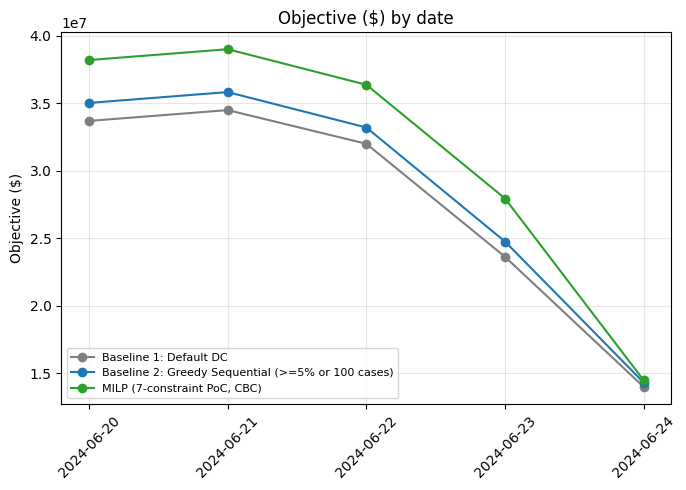

saved -> /content/drive/MyDrive/nestle_dom_data/results/figures/fig1_objective_by_date.png


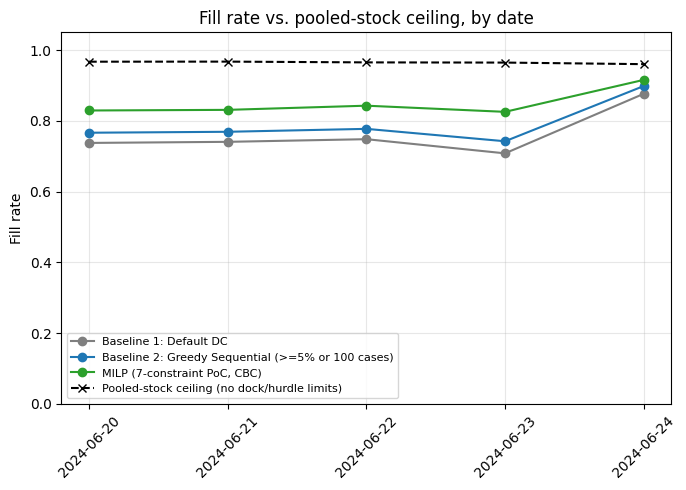

saved -> /content/drive/MyDrive/nestle_dom_data/results/figures/fig2_fill_rate_vs_ceiling_by_date.png


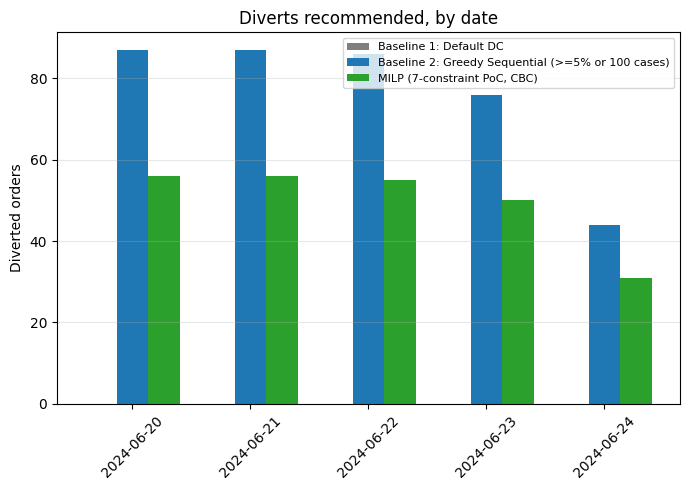

saved -> /content/drive/MyDrive/nestle_dom_data/results/figures/fig3_diverts_by_date.png


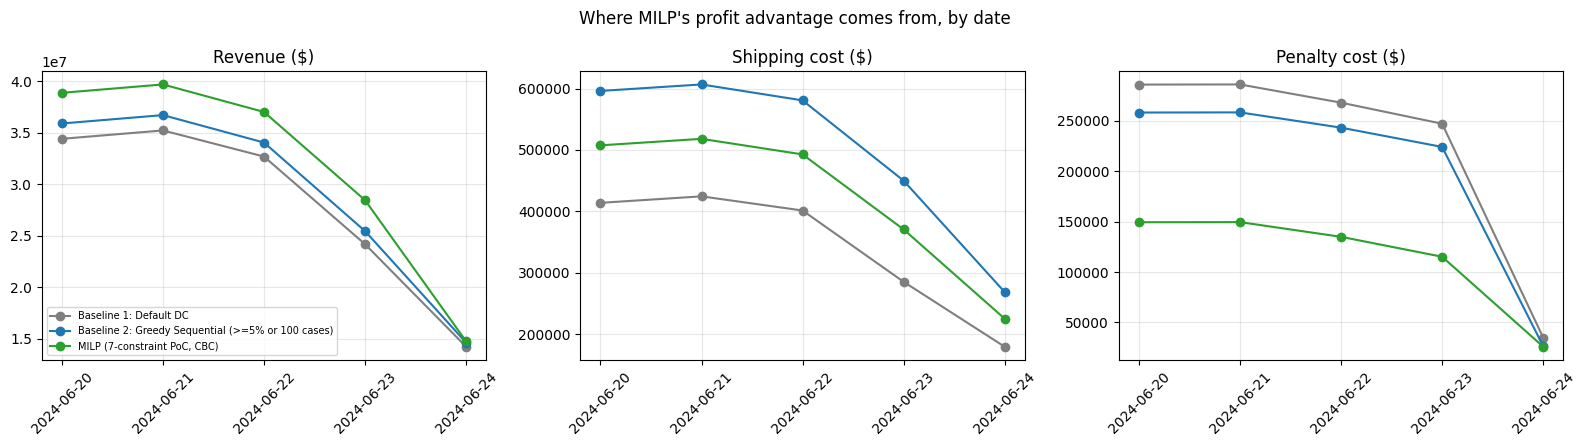

saved -> /content/drive/MyDrive/nestle_dom_data/results/figures/fig4_profit_components_by_date.png


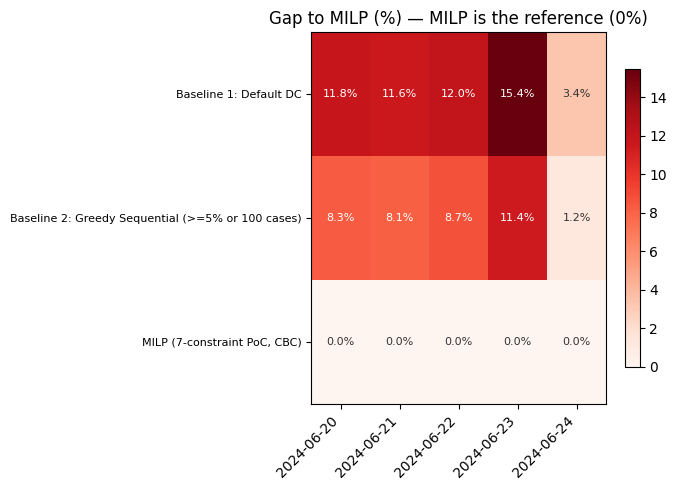

saved -> /content/drive/MyDrive/nestle_dom_data/results/figures/fig5_gap_to_milp_heatmap.png


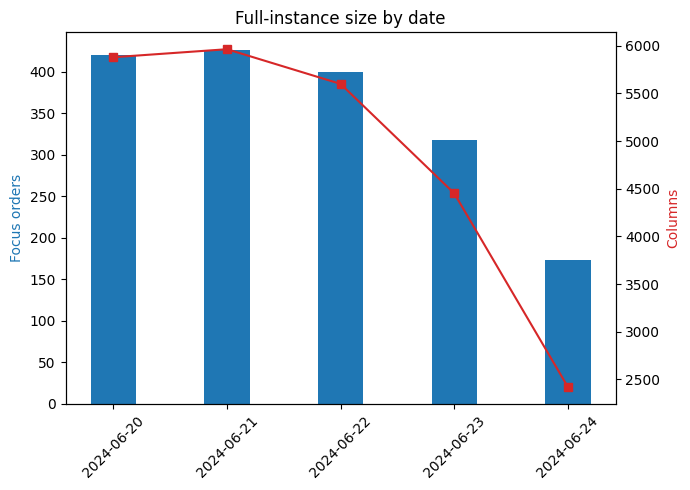

saved -> /content/drive/MyDrive/nestle_dom_data/results/figures/fig6_instance_size_by_date.png

All figures saved to: /content/drive/MyDrive/nestle_dom_data/results/figures


In [8]:
import os
import matplotlib.pyplot as plt

FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

SOLVER_COLOURS = {
    "Baseline 1: Default DC": "#7f7f7f",
    "Baseline 2: Greedy Sequential": "#1f77b4",
    "MILP (7-constraint PoC, CBC)": "#2ca02c",
}
def _colour(solver):
    for key, c in SOLVER_COLOURS.items():
        if solver.startswith(key):
            return c
    return "#333333"

dates = TARGET_DATES
solvers = list(comparison_all["solver"].unique())
x = np.arange(len(dates))

def save_fig(fig, filename):
    fig.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved -> {os.path.join(FIGURES_DIR, filename)}")


# 1. Objective ($) by solver, by date
fig, ax = plt.subplots(figsize=(7, 5))
for s in solvers:
    rows = comparison_all[comparison_all["solver"] == s].set_index("date").reindex(dates)
    ax.plot(dates, rows["objective"], marker="o", label=s, color=_colour(s))
ax.set_title("Objective ($) by date")
ax.set_ylabel("Objective ($)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
save_fig(fig, "fig1_objective_by_date.png")


# 2. Fill rate by solver, by date
def pooled_stock_ceiling(instance):
    info = instance.order_info
    total_demand = sum(l[1] for o in instance.order_ids for l in info[o]["lines"])
    pooled_stock, pooled_demand = {}, {}
    for (p, sku, pgi), v in instance.inventory_cap.items():
        pooled_stock[(sku, pgi)] = pooled_stock.get((sku, pgi), 0.0) + v
    for o in instance.order_ids:
        for sku, qty, *_ in info[o]["lines"]:
            k = (sku, info[o]["pgi"])
            pooled_demand[k] = pooled_demand.get(k, 0.0) + qty
    pooled_fillable = sum(min(d, pooled_stock.get(k, 0.0)) for k, d in pooled_demand.items())
    return pooled_fillable / total_demand if total_demand else 0.0

ceiling_by_date = [pooled_stock_ceiling(results[d]["instance"]) for d in dates]

fig, ax = plt.subplots(figsize=(7, 5))
for s in solvers:
    rows = comparison_all[comparison_all["solver"] == s].set_index("date").reindex(dates)
    ax.plot(dates, rows["fill_rate"], marker="o", label=s, color=_colour(s))
ax.plot(dates, ceiling_by_date, marker="x", linestyle="--", color="black",
        label="Pooled-stock ceiling (no dock/hurdle limits)")
ax.set_title("Fill rate vs. pooled-stock ceiling, by date")
ax.set_ylabel("Fill rate")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
save_fig(fig, "fig2_fill_rate_vs_ceiling_by_date.png")


# 3. Diverts by solver, by date
fig, ax = plt.subplots(figsize=(7, 5))
width = 0.8 / len(solvers)
for i, s in enumerate(solvers):
    rows = comparison_all[comparison_all["solver"] == s].set_index("date").reindex(dates)
    ax.bar(x + i * width, rows["diverts"], width=width, label=s, color=_colour(s))
ax.set_title("Diverts recommended, by date")
ax.set_ylabel("Diverted orders")
ax.set_xticks(x + width * (len(solvers) - 1) / 2)
ax.set_xticklabels(dates, rotation=45)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
save_fig(fig, "fig3_diverts_by_date.png")


# 4. Revenue / shipping / penalty, one panel per component, one line per solver
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, title) in zip(axes, [("revenue", "Revenue ($)"),
                                    ("shipping", "Shipping cost ($)"),
                                    ("penalty", "Penalty cost ($)")]):
    for s in solvers:
        rows = comparison_all[comparison_all["solver"] == s].set_index("date").reindex(dates)
        ax.plot(dates, rows[col], marker="o", label=s, color=_colour(s))
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=7, loc="lower left")
fig.suptitle("Where MILP's profit advantage comes from, by date")
save_fig(fig, "fig4_profit_components_by_date.png")


# 5. Gap-to-MILP heatmap (solver x date)
fig, ax = plt.subplots(figsize=(7, 5))
pivot = comparison_all.pivot(index="solver", columns="date", values="opt_gap_%").reindex(columns=dates)
im = ax.imshow(pivot.values, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                color="white" if val > np.nanmax(pivot.values) / 2 else "#333", fontsize=8)
ax.set_title("Gap to MILP (%) — MILP is the reference (0%)")
fig.colorbar(im, ax=ax, shrink=0.8)
save_fig(fig, "fig5_gap_to_milp_heatmap.png")


# 6. Instance size by date (orders + columns)
fig, ax = plt.subplots(figsize=(7, 5))
rows = run_summary_all.set_index("date").reindex(dates)
ax2 = ax.twinx()
ax.bar(x, rows["n_orders"], width=0.4, color="#1f77b4", label="Focus orders")
ax2.plot(x, rows["n_columns"], marker="s", color="#d62728", label="Columns (orders × DCs)")
ax.set_title("Full-instance size by date")
ax.set_xticks(x)
ax.set_xticklabels(dates, rotation=45)
ax.set_ylabel("Focus orders", color="#1f77b4")
ax2.set_ylabel("Columns", color="#d62728")
save_fig(fig, "fig6_instance_size_by_date.png")

print(f"\nAll figures saved to: {FIGURES_DIR}")
